In [1]:
import pandas as pd
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad



In [3]:
# pretrain = ad.read_h5ad("/home/kchen/microbiome/gut_microbiome_GPT/datasets/hmc_final/pretrain.h5ad")
# dtrain = ad.read_h5ad("/home/kchen/microbiome/gut_microbiome_GPT/datasets/hmc_final/downstream_train.h5ad")
dtest = ad.read_h5ad("/home/kchen/microbiome/gut_microbiome_GPT/datasets/hmc_final/downstream_test.h5ad")

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [7]:
dtest.varm["taxonomy"]

,Domain,Phylum,Class,Order,Family,Genus
Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Atopobiaceae.Tractidigestivibacter,Bacteria,Actinomycetota,Coriobacteriia,Coriobacteriales,Atopobiaceae,Tractidigestivibacter
Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Coriobacteriaceae.Collinsella,Bacteria,Actinomycetota,Coriobacteriia,Coriobacteriales,Coriobacteriaceae,Collinsella
Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Adlercreutzia,Bacteria,Actinomycetota,Coriobacteriia,Coriobacteriales,Eggerthellaceae,Adlercreutzia
Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Senegalimassilia,Bacteria,Actinomycetota,Coriobacteriia,Coriobacteriales,Eggerthellaceae,Senegalimassilia
Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelotrichaceae.Holdemanella,Bacteria,Bacillota,Bacilli,Erysipelotrichales,Erysipelotrichaceae,Holdemanella
...,...,...,...,...,...,...
Bacteria.Marinimicrobia (SAR406 clade).Incertae Sedis.Incertae Sedis.Incertae Sedis.Incertae Sedis,Bacteria,Marinimicrobia (SAR406 clade),Incertae Sedis,Incertae Sedis,Incertae Sedis,Incertae Sedis
Bacteria.Balneolota.Balneolia.Balneolales.Balneolaceae.Balneola,Bacteria,Balneolota,Balneolia,Balneolales,Balneolaceae,Balneola
Bacteria.Pseudomonadota.Gammaproteobacteria.Thiomicrospirales.Thiomicrospiraceae.Thiomicrospira,Bacteria,Pseudomonadota,Gammaproteobacteria,Thiomicrospirales,Thiomicrospiraceae,Thiomicrospira
Bacteria.Bacteroidota.Bacteroidia.Flavobacteriales.Crocinitomicaceae.Brumimicrobium,Bacteria,Bacteroidota,Bacteroidia,Flavobacteriales,Crocinitomicaceae,Brumimicrobium


In [18]:
X = dtest.X

taxonomy = dtest.varm["taxonomy"]

# 1️⃣ Identify columns belonging to each genus
bacteroides_mask = taxonomy["Genus"] == "Bacteroides"
faecali_mask = taxonomy["Genus"] == "Faecalibacterium"

# Total abundance per sample
bacteroides_vars = np.where(bacteroides_mask)[0]
faecali_vars = np.where(faecali_mask)[0]

total = X.sum(axis=1)
bact = X[:, bacteroides_vars].sum(axis=1)
faec = X[:, faecali_vars].sum(axis=1)

# Avoid divide-by-zero
total = np.clip(total, 1e-8, None)

bact_prop = bact / total
faec_prop = faec / total

# Define dominance threshold
threshold = 0.25  # 10%

has_bact = bact_prop > threshold
has_faec = faec_prop > threshold

keep_samples = has_bact & has_faec

dtest_filtered = dtest[keep_samples].copy()

print(f"Kept {keep_samples.sum()} samples")

Kept 20 samples


/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [24]:
dtest_filtered.obs['study_id']

sample
PRJEB5729_ERR443978         PRJEB5729
PRJEB5729_ERR444086         PRJEB5729
PRJEB5729_ERR443998         PRJEB5729
PRJEB5729_ERR444518         PRJEB5729
PRJEB5729_ERR443842         PRJEB5729
PRJEB5729_ERR443974         PRJEB5729
PRJNA516932_SRR8484327    PRJNA516932
PRJNA516932_SRR8484567    PRJNA516932
PRJNA559143_SRR9918248    PRJNA559143
PRJNA428736_SRR6444268    PRJNA428736
PRJEB5729_ERR443978         PRJEB5729
PRJEB5729_ERR444086         PRJEB5729
PRJEB5729_ERR443998         PRJEB5729
PRJEB5729_ERR444518         PRJEB5729
PRJEB5729_ERR443842         PRJEB5729
PRJEB5729_ERR443974         PRJEB5729
PRJNA516932_SRR8484327    PRJNA516932
PRJNA516932_SRR8484567    PRJNA516932
PRJNA559143_SRR9918248    PRJNA559143
PRJNA428736_SRR6444268    PRJNA428736
Name: study_id, dtype: category
Categories (4, object): ['PRJEB5729', 'PRJNA428736', 'PRJNA516932', 'PRJNA559143']

In [27]:
dtest_filtered.write_h5ad("/home/kchen/microbiome/gut_microbiome_GPT/data/conference/pathway.h5ad")

In [46]:
import sys
from pathlib import Path

# Go up two levels to project root
project_root = Path.cwd().parents[1]
sys.path.append(str(project_root))

from data_utils import TaxaVocabulary

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [47]:
import torch
embeddings_dict = torch.load('/home/kchen/microbiome/gut_microbiome_GPT/outputs/eval_pathway/pathway_dict.pt')
vocab = TaxaVocabulary.load('/home/kchen/microbiome/gut_microbiome_GPT/outputs/pretrain_mask_gnn/taxa_vocab.pkl')

In [49]:
vocab.id_to_token

{0: 'Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Atopobiaceae.Tractidigestivibacter',
 1: 'Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Coriobacteriaceae.Collinsella',
 2: 'Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Adlercreutzia',
 3: 'Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Senegalimassilia',
 4: 'Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelotrichaceae.Holdemanella',
 5: 'Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelotrichaceae.NA',
 6: 'Bacteria.Bacillota.Bacilli.Lactobacillales.Lactobacillaceae.Lactiplantibacillus',
 7: 'Bacteria.Bacillota.Bacilli.Lactobacillales.Lactobacillaceae.Limosilactobacillus',
 8: 'Bacteria.Bacillota.Bacilli.Lactobacillales.Lactobacillaceae.Pediococcus',
 9: 'Bacteria.Bacillota.Bacilli.Lactobacillales.Lactobacillaceae.Weissella',
 10: 'Bacteria.Bacillota.Bacilli.Lactobacillales.Streptococcaceae.Streptococcus',
 11: 'Bacteria.Bacillota.Bacilli.RF39.Incertae

In [42]:
embeddings_dict['taxa_ids'].shape

torch.Size([20, 200])

In [72]:
np.where(faecali_mask)[0][0]


30

In [51]:
outputs = embeddings_dict['outputs'][:,1:,:]

In [53]:
outputs.shape

torch.Size([20, 200, 128])

In [54]:
bacteroides_mask
faecali_mask

Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Atopobiaceae.Tractidigestivibacter            False
Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Coriobacteriaceae.Collinsella                 False
Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Adlercreutzia                 False
Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Senegalimassilia              False
Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelotrichaceae.Holdemanella                        False
                                                                                                      ...  
Bacteria.Marinimicrobia (SAR406 clade).Incertae Sedis.Incertae Sedis.Incertae Sedis.Incertae Sedis    False
Bacteria.Balneolota.Balneolia.Balneolales.Balneolaceae.Balneola                                       False
Bacteria.Pseudomonadota.Gammaproteobacteria.Thiomicrospirales.Thiomicrospiraceae.Thiomicrospira       False
Bacteria.Bacteroidota.Bacter

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


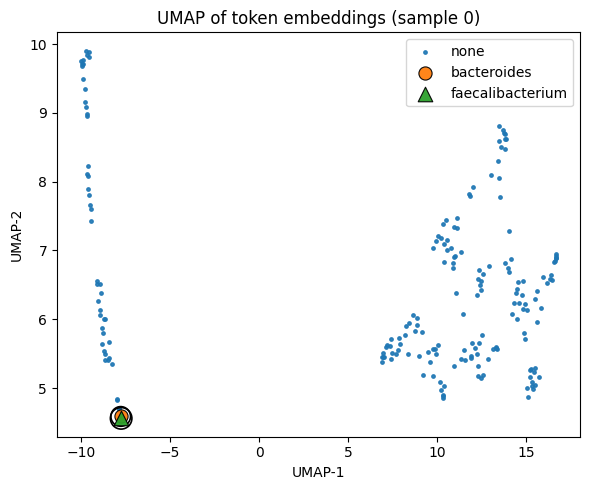

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


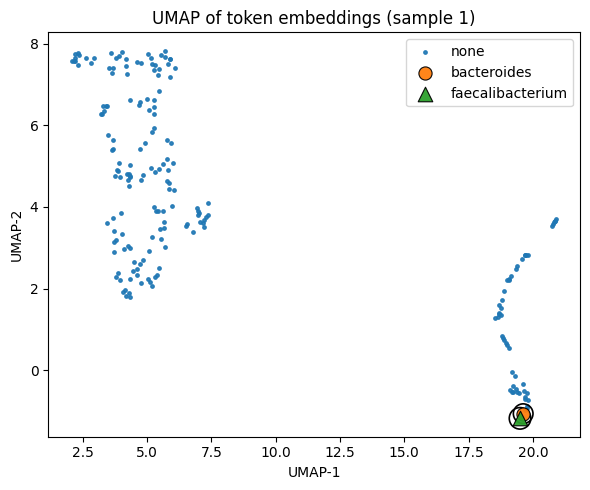

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


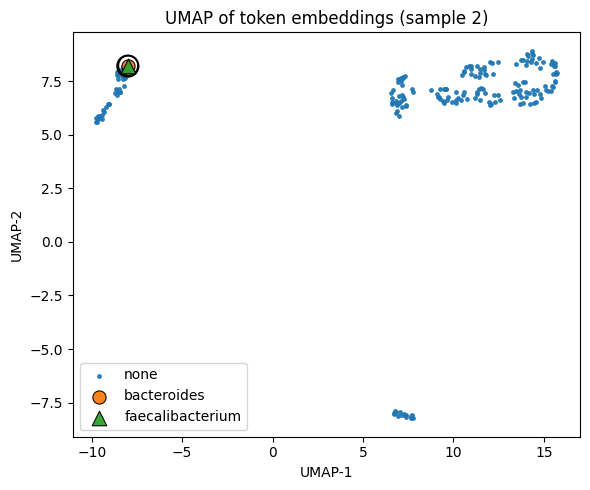

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


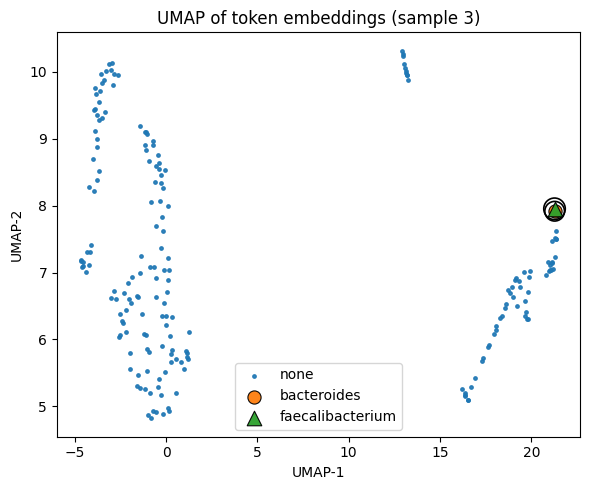

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


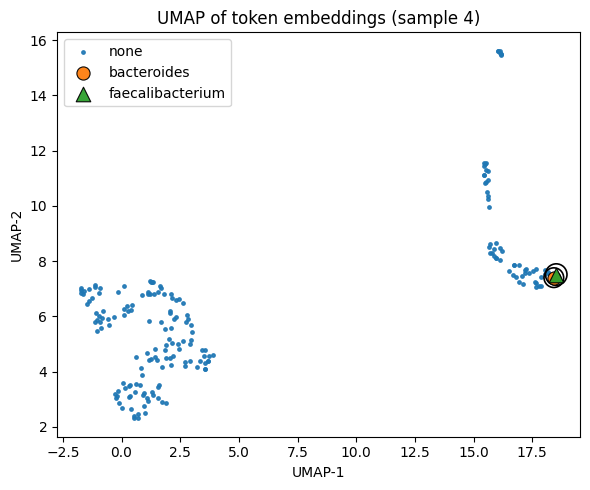

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


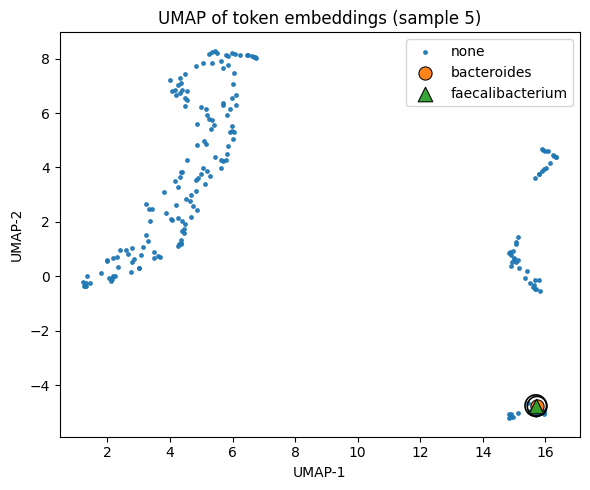

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


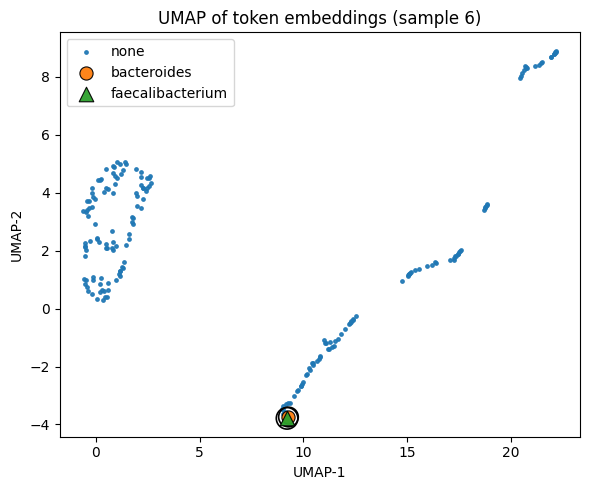

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


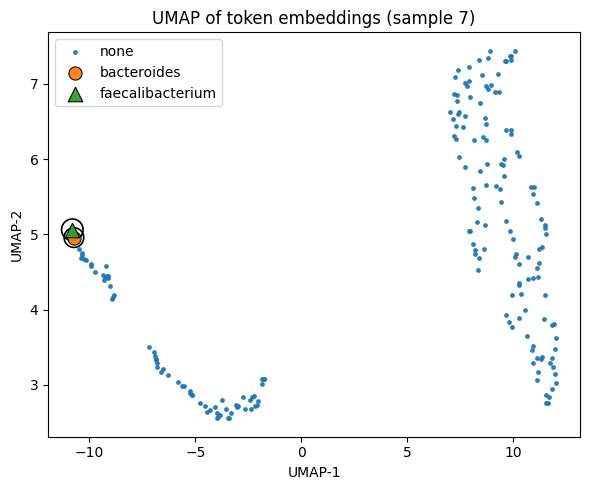

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


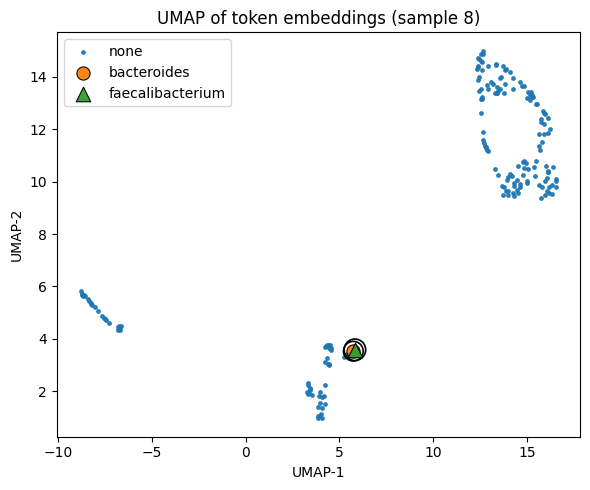

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


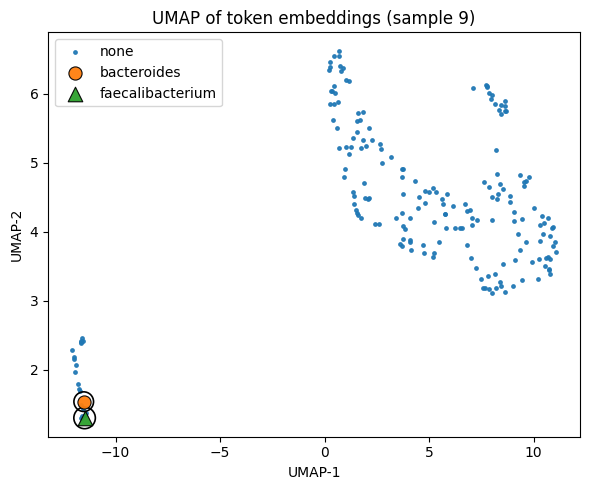

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


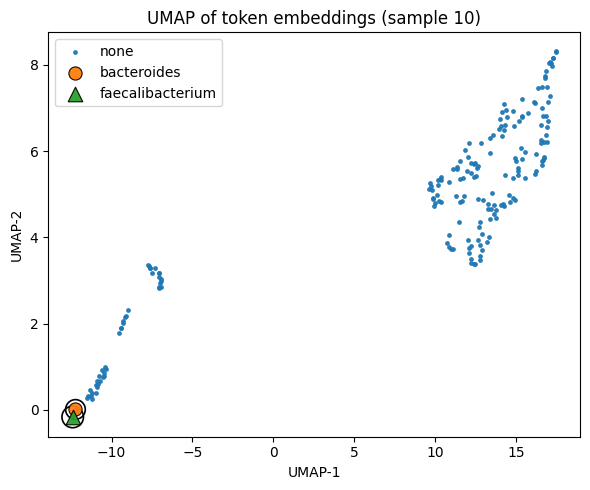

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


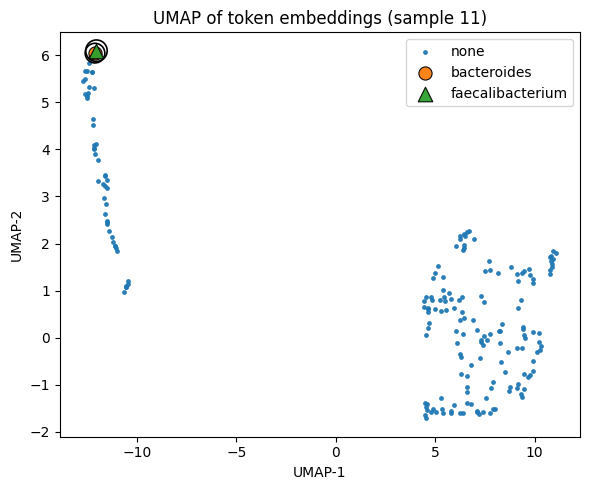

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


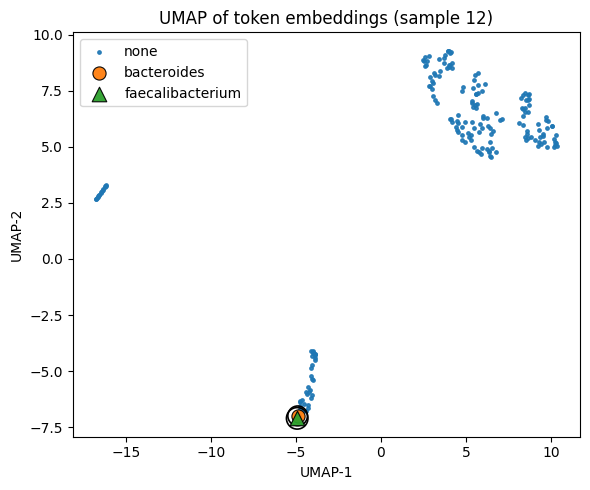

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


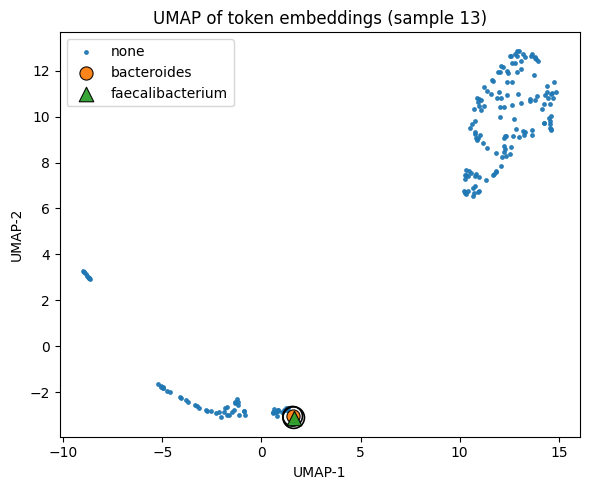

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


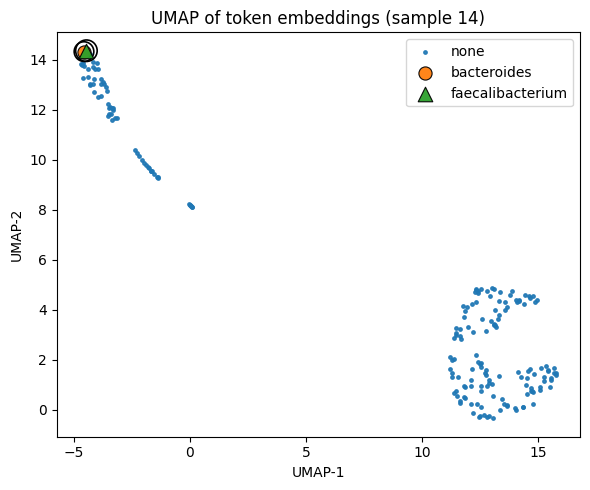

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


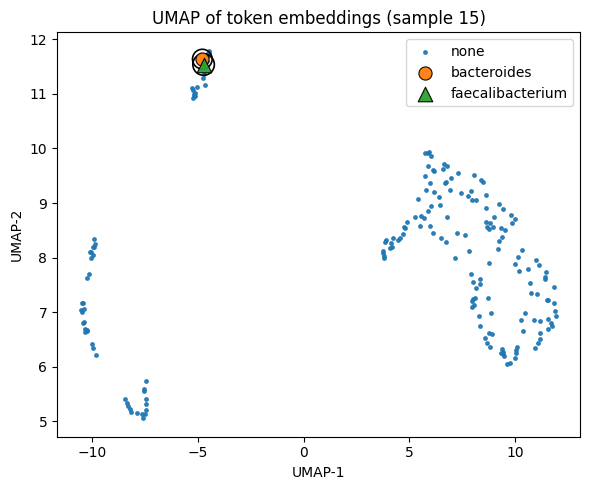

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


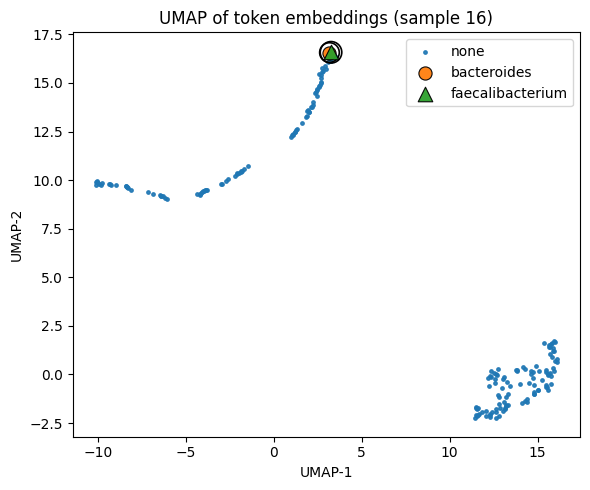

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


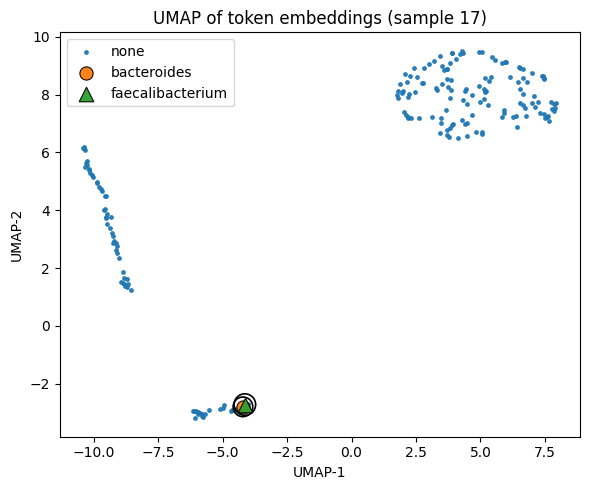

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


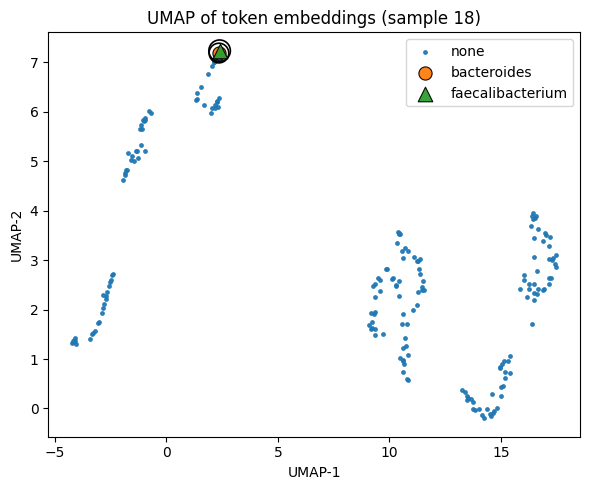

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


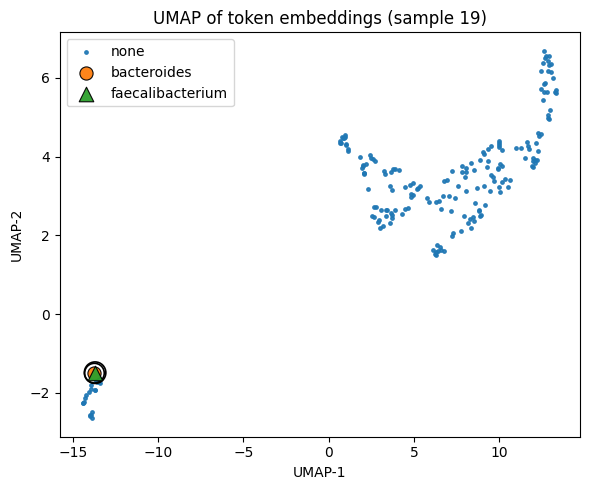

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import umap

# --- pick which of the 20 samples to visualize ---
for sample_idx in range(20):

    taxa_ids = embeddings_dict["taxa_ids"][sample_idx].cpu().numpy()     # (200,)
    E = outputs[sample_idx].detach().cpu().numpy()                      # (200, 128)

    # Make sure masks are numpy arrays indexed by vocab id
    bmask = np.asarray(bacteroides_mask)  # shape (num_taxa,)
    fmask = np.asarray(faecali_mask)      # shape (num_taxa,)

    # --- label each token in the sequence ---
    # If you have special tokens, they might be negative or >= num_taxa.
    labels = np.full(taxa_ids.shape, "none", dtype=object)

    valid = (taxa_ids >= 0) & (taxa_ids < len(bmask))

    labels[valid & bmask[taxa_ids]] = "bacteroides"
    labels[valid & fmask[taxa_ids]] = "faecalibacterium"

    # Optional: inspect a few tokens
    # names = [vocab.id_to_token[int(t)] if (0 <= t < len(bmask)) else "<SPECIAL>" for t in taxa_ids]
    # list(zip(names[:20], labels[:20]))
    # --- UMAP embedding ---

    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        metric="cosine",
        random_state=0,
    )
    Z = reducer.fit_transform(E)  # (200, 2)

    # --- plot ---
    order = ["none", "bacteroides", "faecalibacterium"]
    plt.figure(figsize=(6, 5))

    # 1) Background first: tiny + very transparent
    m_none = labels == "none"
    plt.scatter(
        Z[m_none, 0], Z[m_none, 1],
        s=6, alpha=0.9, label="none",
        zorder=1
    )

    # 2) Bacteroides: bigger + black outline
    m_b = labels == "bacteroides"
    plt.scatter(
        Z[m_b, 0], Z[m_b, 1],
        s=90, alpha=0.95, label="bacteroides",
        edgecolors="black", linewidths=0.8,
        zorder=3
    )

    # 3) Faecalibacterium: different marker + bigger + outline
    m_f = labels == "faecalibacterium"
    plt.scatter(
        Z[m_f, 0], Z[m_f, 1],
        s=110, alpha=0.95, label="faecalibacterium",
        marker="^",
        edgecolors="black", linewidths=0.8,
        zorder=4
    )

    # Optional: halo ring so overlap is obvious
    plt.scatter(Z[m_b, 0], Z[m_b, 1], s=200, facecolors="none", edgecolors="black", linewidths=1.2, zorder=2)
    plt.scatter(Z[m_f, 0], Z[m_f, 1], s=240, facecolors="none", edgecolors="black", linewidths=1.2, zorder=2)

    plt.title(f"UMAP of token embeddings (sample {sample_idx})")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [91]:
import numpy as np
import matplotlib.pyplot as plt
import umap
from sklearn.cluster import DBSCAN

def cluster_and_plot_sample(
    outputs,
    embeddings_dict,
    vocab,
    bacteroides_mask,
    faecali_mask,
    sample_idx,
    eps=0.6,
    min_samples=5,
):
    # ---- extract sample ----
    taxa_ids = embeddings_dict["taxa_ids"][sample_idx].cpu().numpy()
    E = outputs[sample_idx].detach().cpu().numpy()

    bmask = np.asarray(bacteroides_mask)
    fmask = np.asarray(faecali_mask)

    valid = (taxa_ids >= 0) & (taxa_ids < len(bmask))

    is_b = np.zeros_like(taxa_ids, dtype=bool)
    is_f = np.zeros_like(taxa_ids, dtype=bool)

    is_b[valid] = bmask[taxa_ids[valid]]
    is_f[valid] = fmask[taxa_ids[valid]]

    is_highlight = is_b | is_f

    # ---- UMAP ----
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        metric="cosine",
        random_state=0,
    )
    Z = reducer.fit_transform(E)

    # ---- Clustering ----
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(Z)
    cluster_labels = clustering.labels_   # -1 = noise

    # clusters containing highlighted taxa
    highlight_clusters = set(cluster_labels[is_highlight])
    highlight_clusters.discard(-1)

    # ---- Plot ----
    plt.figure(figsize=(7, 6))

    unique_clusters = np.unique(cluster_labels)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_clusters)))

    for cluster_id, color in zip(unique_clusters, colors):
        mask = cluster_labels == cluster_id

        if cluster_id == -1:
            plt.scatter(
                Z[mask, 0], Z[mask, 1],
                s=8, alpha=0.05,
                label="noise",
                color="gray",
                zorder=1
            )
        else:
            plt.scatter(
                Z[mask, 0], Z[mask, 1],
                s=30, alpha=0.6,
                label=f"cluster {cluster_id}",
                color=color,
                zorder=2
            )

    # Overlay highlighted taxa on top
    plt.scatter(
        Z[is_b, 0], Z[is_b, 1],
        s=120,
        edgecolors="black",
        linewidths=1.0,
        label="Bacteroides",
        zorder=4
    )

    plt.scatter(
        Z[is_f, 0], Z[is_f, 1],
        s=120,
        marker="^",
        edgecolors="black",
        linewidths=1.0,
        label="Faecalibacterium",
        zorder=5
    )

    plt.title(f"UMAP + DBSCAN clusters (sample {sample_idx})")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    # ---- Extract taxa in highlight clusters ----
    taxa_in_clusters = []

    for cluster_id in highlight_clusters:
        cluster_mask = cluster_labels == cluster_id
        cluster_taxa_ids = taxa_ids[cluster_mask & valid]
        cluster_names = [vocab.id_to_token[int(t)] for t in cluster_taxa_ids]
        taxa_in_clusters.extend(cluster_names)

    taxa_in_clusters = sorted(set(taxa_in_clusters))
    
    # all clusters
    all_clusters = {}

    unique_clusters = np.unique(cluster_labels)

    for cluster_id in unique_clusters:
        cluster_mask = cluster_labels == cluster_id

        # only keep valid taxa tokens
        cluster_taxa_ids = taxa_ids[cluster_mask & valid]

        cluster_names = [
            vocab.id_to_token[int(t)]
            for t in cluster_taxa_ids
        ]

        all_clusters[int(cluster_id)] = sorted(set(cluster_names))


    return {
        "highlight_clusters": sorted(list(highlight_clusters)),
        "taxa_in_clusters": taxa_in_clusters,
        "all_clusters": all_clusters
    }


/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


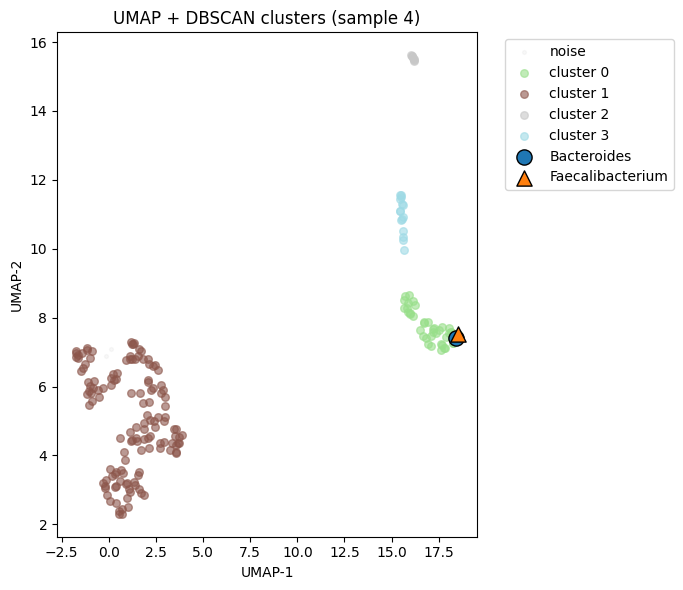

Clusters containing highlighted taxa: [0]
Taxa in those clusters:
Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Coriobacteriaceae.Collinsella
Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelotrichaceae.Holdemanella
Bacteria.Bacillota.Bacilli.Lactobacillales.Streptococcaceae.Streptococcus
Bacteria.Bacillota.Bacilli.NA.NA.NA
Bacteria.Bacillota.Clostridia.Clostridia UCG-014.Incertae Sedis.Incertae Sedis
Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.Agathobacter
Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.Anaerostipes
Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.Blautia
Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.Eisenbergiella
Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.Fusicatenibacter
Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.Lachnospiraceae NK4B4 group
Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.Lachnospiraceae UCG-004
Bacteria.Bacillota.Clostridia.Lachn

In [95]:
result = cluster_and_plot_sample(
    outputs,
    embeddings_dict,
    vocab,
    bacteroides_mask,
    faecali_mask,
    sample_idx=4,
    eps=0.6,
    min_samples=5,
)

print("Clusters containing highlighted taxa:", result["highlight_clusters"])
print("Taxa in those clusters:")
print("\n".join(result["taxa_in_clusters"][:50]))


In [96]:
result['all_clusters']

{-1: ['Archaea.Halobacteriota.Methanosarcinia.Methanosarcinales.Methanosarcinaceae.Methanolobus',
  'Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Slackia'],
 0: ['Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Coriobacteriaceae.Collinsella',
  'Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelotrichaceae.Holdemanella',
  'Bacteria.Bacillota.Bacilli.Lactobacillales.Streptococcaceae.Streptococcus',
  'Bacteria.Bacillota.Bacilli.NA.NA.NA',
  'Bacteria.Bacillota.Clostridia.Clostridia UCG-014.Incertae Sedis.Incertae Sedis',
  'Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.Agathobacter',
  'Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.Anaerostipes',
  'Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.Blautia',
  'Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.Eisenbergiella',
  'Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.Fusicatenibacter',
  'Bacteria.Bacillota.Clostridia.Lachn